<a href="https://colab.research.google.com/github/fbeilstein/bioinformatics/blob/master/practice_04_bulk_RNA_sequence_quantification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Transcribing the Message (Bulk RNA-Seq Quantification)**

In this notebook, we transition from analyzing static genomic DNA to measuring dynamic gene expression. The biological mechanisms driving these dynamics include RNA Polymerase II promoter kinetics, transcription factor initiation, alternative splicing, and mRNA turnover rates. Our primary challenge is distinguishing true biological variance from the technical noise inherent in the sequencing process.

The instrumental method generating our data is **Bulk RNA-seq**. The workflow involves extracting total RNA, isolating mRNA via poly-A selection, performing reverse transcription to generate cDNA, applying PCR amplification, and finally cDNA sequencing.

Our dataset consists of a Saccharomyces cerevisiae (yeast) count matrix comparing Wild-Type (WT) cells against cells subjected to Heat Shock. The raw reads were previously quantified using **kallisto**, an ultra-fast pseudoalignment tool. Our goal today is to model these overdispersed RNA read counts using **Negative Binomial Generalized Linear Models (GLMs)** with empirical Bayes dispersion shrinkage, implemented via **PyDESeq2**.

### **Part 1: Environment Setup**

We will utilize `PyDESeq2`, a Python implementation of the industry-standard DESeq2 algorithm originally written in R. It models count data using negative binomial distributions and tests for differential expression.


In [1]:

import os
from IPython.display import clear_output

# Install PyDESeq2 and necessary statistical/plotting libraries

!pip install -q pydeseq2 pandas numpy scipy matplotlib seaborn openpyxl

clear_output()
print("Installations successful.")

Installations successful.


### **Part 2: Dataset Download**

We are analyzing a real count matrix of *Saccharomyces cerevisiae* from NCBI GEO (**GSE135568**). This study subjected wild-type yeast to heat shock (39°C for 20 minutes) vs a control (30°C).
We will download the raw count matrix directly from the GEO FTP server, extract 3 Wild-Type replicates and 3 Heat-Shock replicates, and save them locally.

In [7]:

import urllib.request
import pandas as pd
import os
from IPython.display import clear_output

print("Downloading real Saccharomyces cerevisiae RNA-seq dataset from GEO (GSE135568)...")
print("This is a ~5MB Excel file, it may take a few moments.")
url = "ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE135nnn/GSE135568/suppl/GSE135568_CountMatrixRNAseq.xlsx"
urllib.request.urlretrieve(url, "GSE135568_CountMatrixRNAseq.xlsx")

print("Processing count matrix...")
df = pd.read_excel("GSE135568_CountMatrixRNAseq.xlsx", index_col=0)
df.columns = df.columns.str.strip() # Remove any trailing/leading spaces

# Select 3 Wild-Type replicates and 3 Heat-Shock (39C, 20m) replicates
wt_cols = ["wt.30.0.1", "wt.30.0.2", "wt.30.0.3"]
hs_cols = ["wt.39.20.1", "wt.39.20.2", "wt.39.20.3"]
counts_df = df[wt_cols + hs_cols].copy()

# Rename columns to match our expected format
new_col_names = ["WT_1", "WT_2", "WT_3", "HS_1", "HS_2", "HS_3"]
counts_df.columns = new_col_names

# Save count matrix
counts_df.to_csv("yeast_heat_shock_counts.csv")

# Generate matching metadata
metadata_df = pd.DataFrame({
    "condition": ["WT", "WT", "WT", "HeatShock", "HeatShock", "HeatShock"]
}, index=new_col_names)
metadata_df.to_csv("yeast_metadata.csv")

# Cleanup the downloaded file
os.remove("GSE135568_CountMatrixRNAseq.xlsx")

clear_output()
print("Real GEO dataset (GSE135568) successfully downloaded and processed.")


Real GEO dataset (GSE135568) successfully downloaded and processed.


### **Part 3: Exploring the Count Matrix and Overdispersion**

In RNA-seq, technical replicates often follow a Poisson distribution, where the variance equals the mean ($Var = \mu$). However, biological replicates exhibit **overdispersion** ($Var > \mu$) due to complex biological regulatory networks and environmental fluctuations.

Let's load the count matrix and verify this mean-variance relationship.


--- Count Matrix Shape ---
(7126, 6)

--- First 3 Genes ---
         WT_1  WT_2  WT_3  HS_1  HS_2  HS_3
YIL100W     7     0     2    14     4     8
YDR130C   293   365   253   343   317   316
YDR473C   293   162   179   270   208   238


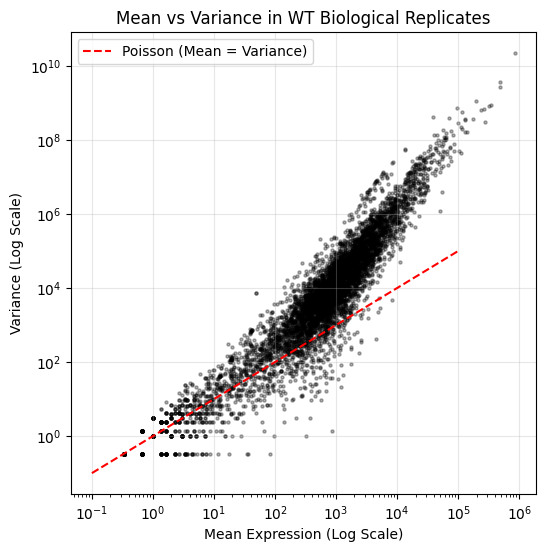

In [8]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load count data and set gene IDs as index

counts_df = pd.read_csv("yeast_heat_shock_counts.csv", index_col=0)
metadata_df = pd.read_csv("yeast_metadata.csv", index_col=0)

print("--- Count Matrix Shape ---")
print(counts_df.shape)

print("\n--- First 3 Genes ---")
print(counts_df.head(3))

# Calculate mean and variance across the WT biological replicates

wt_samples = metadata_df[metadata_df["condition"] == "WT"].index
wt_counts = counts_df[wt_samples]

gene_means = wt_counts.mean(axis=1)
gene_vars = wt_counts.var(axis=1)

# Plot Mean vs Variance

plt.figure(figsize=(6, 6))
plt.scatter(gene_means, gene_vars, alpha=0.3, s=5, color="black")
plt.plot([0.1, 100000], [0.1, 100000], color="red", linestyle="--", label="Poisson (Mean = Variance)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Mean Expression (Log Scale)")
plt.ylabel("Variance (Log Scale)")
plt.title("Mean vs Variance in WT Biological Replicates")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### **Part 4: Negative Binomial GLM Theory**

Because of overdispersion, RNA-seq counts ($K_{ij}$ for gene $i$ in sample $j$) are modeled using a Negative Binomial (NB) distribution:


$$K_{ij} \sim \text{NB}(\mu_{ij}, \alpha_i)$$

The variance is defined as:


$$Var = \mu_{ij} + \alpha_i \mu_{ij}^2$$

Where:

* $\mu_{ij}$ is the expected mean count, driven by the condition (e.g., WT vs Heat Shock).
* $\alpha_i$ is the gene-specific **dispersion parameter**.

To accurately estimate $\alpha_i$ with only 3 replicates, PyDESeq2 uses **Empirical Bayes**. It shares information across all genes, "shrinking" extreme dispersion estimates toward a consensus trend. This prevents genes with artificially low variance from generating false positive differential expression calls.

### **Part 5: Differential Expression Analysis with PyDESeq2**

We will now initialize the `DeseqDataSet`, fit the GLMs, and extract the statistical summary for the Heat Shock vs WT contrast.

In [14]:

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# 1. Initialize the DESeq2 Dataset
dds = DeseqDataSet(
    counts=counts_df.T,    # PyDESeq2 expects genes as columns, samples as rows
    metadata=metadata_df,
    design="~ condition"   # Updated R-style formula
)

# 2. Fit the Negative Binomial GLMs and calculate dispersions

print("Fitting GLMs and applying Empirical Bayes shrinkage...")
dds.deseq2()

# 3. Extract Differential Expression Results

# We specify the contrast: ["factor", "numerator", "denominator"]

stat_res = DeseqStats(dds, contrast=["condition", "HeatShock", "WT"])
stat_res.summary()

res_df = stat_res.results_df
print("\n--- Top 5 Differentially Expressed Genes (by p-value) ---")
print(res_df.sort_values("padj").head(5))


Fitting GLMs and applying Empirical Bayes shrinkage...
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 8.86 seconds.

Fitting dispersion trend curve...
... done in 0.24 seconds.

Fitting MAP dispersions...
... done in 11.42 seconds.

Fitting LFCs...
... done in 4.78 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: condition HeatShock vs WT
            baseMean  log2FoldChange     lfcSE      stat        pvalue  \
YIL100W     5.491004        1.160005  1.070503  1.083608  2.785387e-01   
YDR130C   313.571051       -0.253581  0.159753 -1.587332  1.124374e-01   
YDR473C   224.169002       -0.186421  0.242858 -0.767613  4.427171e-01   
YKL175W  3013.666219        0.071978  0.098013  0.734367  4.627251e-01   
YDR239C  1197.969767       -0.100752  0.119382 -0.843948  3.986984e-01   
...              ...             ...       ...       ...           ...   
YIL135C   532.072906       -0.065259  0.186936 -0.349100  7.270145e-01   
YDL124W  8982.823468        1.245453  0.127176  9.793112  1.205282e-22   
YDR198C  1006.549930        0.106081  0.137383  0.772155  4.400225e-01   
YIL134W   655.469885        0.248173  0.144009  1.723316  8.483140e-02   
YBR230C   428.647895        0.709517  0.189911  3.736051  1.869330e-04   

                 padj  
YIL100W  4.190840e-01  

... done in 3.16 seconds.



### **Part 6: Visualizing Results (Volcano Plot)**

A Volcano Plot visually separates genes by their biological effect size (Log2 Fold Change) on the x-axis and their statistical significance (-Log10 p-value) on the y-axis.

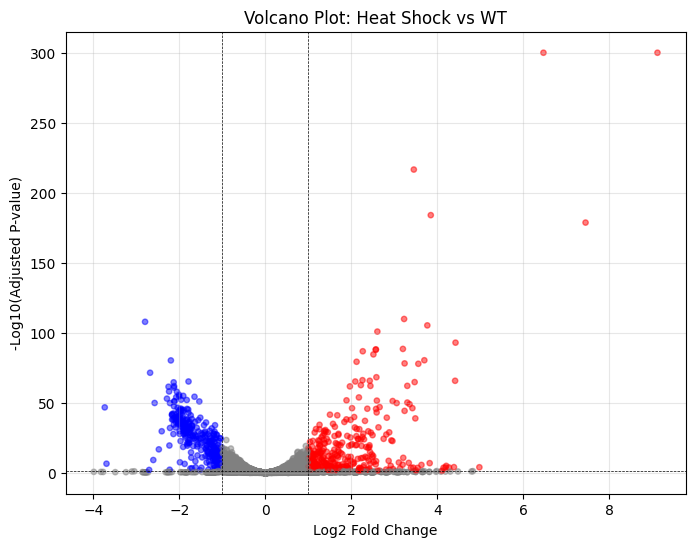

In [16]:
# Filter out genes with NaN adjusted p-values
plot_df = res_df.dropna(subset=["padj", "log2FoldChange"]).copy()

# Calculate -log10(padj)
plot_df["neg_log_pval"] = -np.log10(plot_df["padj"].clip(lower=1e-300))

# Classify genes for coloring
plot_df["status"] = "Not Significant"
plot_df.loc[(plot_df["padj"] < 0.05) & (plot_df["log2FoldChange"] > 1), "status"] = "Upregulated"
plot_df.loc[(plot_df["padj"] < 0.05) & (plot_df["log2FoldChange"] < -1), "status"] = "Downregulated"

color_map = {"Not Significant": "grey", "Upregulated": "red", "Downregulated": "blue"}

plt.figure(figsize=(8, 6))
plt.scatter(plot_df["log2FoldChange"], plot_df["neg_log_pval"],
c=plot_df["status"].map(color_map), alpha=0.5, s=15)

plt.axvline(x=1, color='black', linestyle='--', linewidth=0.5)
plt.axvline(x=-1, color='black', linestyle='--', linewidth=0.5)
plt.axhline(y=-np.log10(0.05), color='black', linestyle='--', linewidth=0.5)

plt.title("Volcano Plot: Heat Shock vs WT")
plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10(Adjusted P-value)")
plt.grid(True, alpha=0.3)
plt.show()


### **Part 7: Biological Interpretation**

When yeast is exposed to severe heat, standard translation is halted. Transcription factors like Hsf1 trigger the rapid transcription of Heat Shock Proteins (HSPs). These act as molecular chaperones, refolding denatured proteins to prevent cellular aggregation.

Let's check the Log2 Fold Change of **HSP104** (YLL026W) and **SSA1** (YAL005C), two classic molecular chaperones.

In [17]:
hsp_genes = ["YLL026W", "YAL005C"]
for gene in hsp_genes:
  if gene in res_df.index:
    l2fc = res_df.loc[gene, "log2FoldChange"]
    padj = res_df.loc[gene, "padj"]
    print(f"{gene}: Log2FC = {l2fc:.2f}, p-adj = {padj:.2e}")


YLL026W: Log2FC = 3.47, p-adj = 1.83e-65
YAL005C: Log2FC = 2.59, p-adj = 3.15e-52


### **Part 8: Dispersion Calculation by Hand**

Let's manually compute the dispersion parameter $\alpha$ for a single gene across 3 WT replicates without empirical shrinkage.
Given the formula $Var = \mu + \alpha \mu^2$, solving for $\alpha$ yields:
$$
\alpha = \frac{Var - \mu}{\mu^2}
$$


In [18]:
gene_x_counts = np.array([450, 620, 510])

mu = np.mean(gene_x_counts)
var = np.var(gene_x_counts, ddof=1) # Sample variance

alpha = (var - mu) / (mu**2)

print(f"Mean (µ): {mu:.2f}")
print(f"Variance (Var): {var:.2f}")
print(f"Calculated Dispersion (α): {alpha:.5f}")

if var > mu:
  print("Variance exceeds mean: Overdispersion is present.")
else:
  print("Variance equals or is less than mean: Poisson assumption holds.")

Mean (µ): 526.67
Variance (Var): 7433.33
Calculated Dispersion (α): 0.02490
Variance exceeds mean: Overdispersion is present.


### **Homework: Transcriptomics Classification & Analysis**

Use the tools and concepts demonstrated above to analyze the differential expression results.


#### **Task 1: Low-Count Filter**

Raw count matrices contain many genes with zero or near-zero reads across all samples, which adds statistical noise.
Implement the `filter_low_counts` function to read `counts_df` and return a dataframe retaining only genes where the sum of reads across all samples is $\geq 10$.


In [ ]:
def filter_low_counts(df, min_sum=10):
  """
  Reads a count dataframe and returns a filtered dataframe.
  """
  # ---- YOUR CODE HERE ----
  return df


# filtered_counts = filter_low_counts(counts_df)
# print(f"Remaining genes: {filtered_counts.shape[0]}")

#### **Task 2: MA Plot**

An MA plot visualizes the log2 fold change (M) against the mean normalized counts (A).
Extract the `baseMean` and `log2FoldChange` from `res_df`. Plot these values using `matplotlib`.
*Note: You must apply a log10 transformation to the x-axis (baseMean) to clearly see the distribution.*

In [ ]:
# ---- YOUR CODE HERE ----

#### **Task 3: Implement the Negative Binomial PMF**

Using `scipy.stats.nbinom`, implement `nb_probability` which takes a count $k$, a mean $\mu$, and a dispersion $\alpha$, and returns the probability mass function (PMF) value.
*Hint: scipy parameterizes the negative binomial using `n` (number of successes) and `p` (probability of success). You will need to convert $\mu$ and $\alpha$ into $n$ and $p$ using $n = 1/\alpha$ and $p = n / (n + \mu)$.*

In [ ]:

from scipy.stats import nbinom

def nb_probability(k, mu, alpha):
  """
  Returns the probability of observing count k given mean and dispersion.
  """
  # ---- YOUR CODE HERE ----
  return 0.0

#### **Task 4: Extract Top Regulators**

Using the PyDESeq2 `res_df` table, extract the indices (Gene IDs) of the top 10 significantly upregulated genes (sorted by highest `log2FoldChange`, requiring `padj` < 0.01). Store them in a list called `top_10_up`.

In [ ]:
# ---- YOUR CODE HERE ----

#### **Task 5: Interpretation Questions**

Answer the following in a text cell:

1. A gene has a mean expression $\mu = 100$ and a dispersion $\alpha = 0.05$. What is its expected variance under the Negative Binomial model?
2. Why is poly-A selection performed during library preparation instead of sequencing total RNA?
3. What is the fundamental difference between standard alignment (e.g., STAR/HISAT2) and pseudoalignment (e.g., kallisto)?
4. Why does empirical Bayes shrinkage primarily affect genes with very low raw counts?
5. Distinguish between biological variance and technical noise in the context of an RNA-Seq experiment.